# WASP-189b Emission Spectral Diagnostics

Standalone diagnostic notebook for the prepared high-resolution emission spectra under `input/hrs/emission/wasp189b/`. This notebook only reads prepared bundles and plots diagnostics; it does not regenerate data products.

## Config

`KP_OVERRIDE` and `VSYS_OVERRIDE` are intentionally off by default. If the config has missing values, the line microscope will skip planet-trail/planet-frame behavior until you fill the config or set an explicit override here.

In [1]:
PLANET = 'WASP-189b'
PLANET_SLUG = 'wasp189b'
MODE = 'emission'
EPOCHS = ('20230327',)
ARMS = ("blue", "red")

# Leave these as None unless you explicitly want notebook-local values.
EPHEMERIS = None  # If None, infer from timeseries_prep.json when available.
KP_OVERRIDE = None
VSYS_OVERRIDE = None

PHASE_ROWS_TOP_TO_BOTTOM = True
PHASE_AXIS = "phase_mod1" if MODE == "emission" else "phase"
MATRIX_PERCENTILE = 99.5
PROFILE_MAX_BINS = 1400
OBSERVED_MAX_BINS = 750
COLLAPSED_MAX_BINS = 900
MASK_SIGMA_THRESHOLD = 0.5

LINE_WINDOW_KMS = 150.0
LINE_BIN_KMS = 2.0
MAX_EPOCHS_TO_PLOT = None  # Set to an integer while iterating quickly.

In [2]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "config.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import config
from config_utils import get_params

DATA_ROOT = REPO_ROOT / "input" / "hrs" / MODE / PLANET_SLUG
LRS_ROOT = REPO_ROOT / "input" / "lrs" / MODE / PLANET_SLUG
PHOT_ROOT = REPO_ROOT / "input" / "phot" / MODE / PLANET_SLUG
CKMS = 299792.458

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

DATA_ROOT

PosixPath('/Users/calder/code/atmo-retrieval/input/hrs/emission/wasp189b')

## Load Prepared Bundles

In [3]:
def _load_optional_array(path: Path):
    return np.load(path, allow_pickle=True) if path.exists() else None


def load_bundle(epoch: str, arm: str) -> dict | None:
    path = DATA_ROOT / epoch / arm
    required = ("wavelength.npy", "data.npy", "sigma.npy", "phase.npy")
    missing = [name for name in required if not (path / name).exists()]
    if missing:
        print(f"Skipping {path.relative_to(REPO_ROOT)}: missing {missing}")
        return None

    meta_path = path / "timeseries_prep.json"
    meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
    bundle = {
        "epoch": epoch,
        "arm": arm,
        "path": path,
        "wavelength": np.asarray(np.load(path / "wavelength.npy"), dtype=float),
        "data": np.asarray(np.load(path / "data.npy"), dtype=float),
        "sigma": np.asarray(np.load(path / "sigma.npy"), dtype=float),
        "phase": np.asarray(np.load(path / "phase.npy"), dtype=float),
        "jd": _load_optional_array(path / "jd.npy"),
        "airmass": _load_optional_array(path / "airmass.npy"),
        "snr": _load_optional_array(path / "snr.npy"),
        "exptime": _load_optional_array(path / "exptime.npy"),
        "pre_sysrem_data": _load_optional_array(path / "pre_sysrem_data.npy"),
        "pre_sysrem_sigma": _load_optional_array(path / "pre_sysrem_sigma.npy"),
        "meta": meta,
    }
    names = (f"wavelength_{MODE}.npy", f"spectrum_{MODE}.npy", f"uncertainty_{MODE}.npy")
    if all((path / name).exists() for name in names):
        bundle["collapsed"] = {
            "wavelength": np.asarray(np.load(path / names[0]), dtype=float),
            "spectrum": np.asarray(np.load(path / names[1]), dtype=float),
            "uncertainty": np.asarray(np.load(path / names[2]), dtype=float),
        }
    else:
        bundle["collapsed"] = None
    sysrem_path = path / "U_sysrem.npz"
    bundle["sysrem"] = np.load(sysrem_path, allow_pickle=True) if sysrem_path.exists() else None
    return bundle


def load_all_bundles() -> list[dict]:
    records = []
    for epoch in EPOCHS:
        for arm in ARMS:
            if not (DATA_ROOT / epoch / arm).exists():
                continue
            bundle = load_bundle(epoch, arm)
            if bundle is not None:
                records.append(bundle)
    return records


bundles = load_all_bundles()
bundles_by_key = {(b["epoch"], b["arm"]): b for b in bundles}
inferred_ephemerides = [b["meta"].get("ephemeris") for b in bundles if b["meta"].get("ephemeris")]
RESOLVED_EPHEMERIS = EPHEMERIS or (inferred_ephemerides[0] if inferred_ephemerides else None)
planet_cfg = None
if RESOLVED_EPHEMERIS is not None:
    try:
        planet_cfg = get_params(PLANET, RESOLVED_EPHEMERIS)
    except Exception as exc:
        print(f"Could not load config parameters for {PLANET} / {RESOLVED_EPHEMERIS}: {exc}")
print(f"Loaded {len(bundles)} prepared bundles from {DATA_ROOT.relative_to(REPO_ROOT)}")
print(f"Ephemeris: {RESOLVED_EPHEMERIS}")

Loaded 2 prepared bundles from input/hrs/emission/wasp189b
Ephemeris: Lendl20


## Helpers

In [4]:
def finite_good(data, sigma=None):
    mask = np.isfinite(data)
    if sigma is not None:
        mask &= np.isfinite(sigma) & (sigma > 0) & (sigma < MASK_SIGMA_THRESHOLD)
    return mask


def robust_limits(values, percentile=MATRIX_PERCENTILE, symmetric=True, floor=None):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    if symmetric:
        vmax = float(np.nanpercentile(np.abs(arr), percentile))
        if floor is not None:
            vmax = max(vmax, floor)
        if not np.isfinite(vmax) or vmax <= 0:
            return None
        return -vmax, vmax
    lo = float(np.nanpercentile(arr, 100.0 - percentile))
    hi = float(np.nanpercentile(arr, percentile))
    if floor is not None and hi - lo < floor:
        mid = 0.5 * (lo + hi)
        lo, hi = mid - floor / 2, mid + floor / 2
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None
    return lo, hi


def display_wavelength_nm(wave_angstrom):
    return np.asarray(wave_angstrom, dtype=float) / 10.0


def phase_values(bundle):
    if PHASE_AXIS == "phase_mod1":
        meta_min = bundle["meta"].get("phase_mod1_min")
        phase = np.mod(bundle["phase"], 1.0)
        if meta_min is None:
            return phase
        return phase
    return bundle["phase"]


def phase_order(bundle):
    order = np.argsort(phase_values(bundle))
    if not PHASE_ROWS_TOP_TO_BOTTOM:
        order = order[::-1]
    return order


def gap_aware_bins(wave, max_bins=700, gap_factor=8.0):
    wave = np.asarray(wave, dtype=float)
    good = np.flatnonzero(np.isfinite(wave))
    if good.size == 0:
        return []
    diffs = np.diff(wave[good])
    finite_diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if finite_diffs.size:
        gap_limit = gap_factor * np.nanmedian(finite_diffs)
        groups = np.split(good, np.flatnonzero(diffs > gap_limit) + 1)
    else:
        groups = [good]
    bins = []
    for group in groups:
        if group.size == 0:
            continue
        bin_width = max(1, int(math.ceil(group.size / max_bins)))
        n_chunks = max(1, int(math.ceil(group.size / bin_width)))
        bins.extend([chunk for chunk in np.array_split(group, n_chunks) if chunk.size])
    return bins


def binned_series(wave, values, errors=None, max_bins=700):
    wave = np.asarray(wave, dtype=float)
    values = np.asarray(values, dtype=float)
    errors = None if errors is None else np.asarray(errors, dtype=float)
    wb, vb, eb = [], [], []
    for idx in gap_aware_bins(wave, max_bins=max_bins):
        w = wave[idx]
        v = values[idx]
        if errors is not None:
            e = errors[idx]
            good = np.isfinite(w) & np.isfinite(v) & np.isfinite(e) & (e > 0) & (e < MASK_SIGMA_THRESHOLD)
            if np.any(good):
                weight = 1.0 / np.square(e[good])
                wb.append(float(np.average(w[good], weights=weight)))
                vb.append(float(np.average(v[good], weights=weight)))
                eb.append(float(np.sqrt(1.0 / np.sum(weight))))
                continue
        good = np.isfinite(w) & np.isfinite(v)
        if np.any(good):
            wb.append(float(np.nanmean(w[good])))
            vb.append(float(np.nanmean(v[good])))
            eb.append(float(np.nanstd(v[good]) / max(1.0, np.sqrt(np.count_nonzero(good)))))
    return np.asarray(wb), np.asarray(vb), np.asarray(eb)


def column_stats(bundle):
    data = np.asarray(bundle["data"], dtype=float)
    sigma = np.asarray(bundle["sigma"], dtype=float)
    good = finite_good(data, sigma)
    weight = np.where(good, 1.0 / np.square(sigma), 0.0)
    wsum = np.sum(weight, axis=0)
    mean = np.divide(
        np.sum(np.where(good, data * weight, 0.0), axis=0),
        wsum,
        out=np.full(data.shape[1], np.nan),
        where=wsum > 0,
    )
    err_mean = np.divide(1.0, np.sqrt(wsum), out=np.full(data.shape[1], np.nan), where=wsum > 0)
    typical_sigma = np.sqrt(np.nanmean(np.where(good, np.square(sigma), np.nan), axis=0))
    count = np.sum(good, axis=0)
    scatter = np.nanstd(np.where(good, data, np.nan), axis=0)
    scatter = np.where(count >= 2, scatter, np.nan)
    return {"mean": mean, "err_mean": err_mean, "typical_sigma": typical_sigma, "scatter": scatter, "count": count}


def config_float(name):
    if planet_cfg is None:
        return np.nan
    try:
        return float(planet_cfg.get(name, np.nan))
    except Exception:
        return np.nan


def resolved_kp():
    if KP_OVERRIDE is not None:
        return float(KP_OVERRIDE)
    value = config_float("Kp")
    return value if np.isfinite(value) else None


def resolved_vsys():
    if VSYS_OVERRIDE is not None:
        return float(VSYS_OVERRIDE)
    value = config_float("RV_abs")
    return value if np.isfinite(value) else None


def planet_velocity_kms(phase):
    kp = resolved_kp()
    if kp is None:
        return None
    return kp * np.sin(2.0 * np.pi * np.asarray(phase, dtype=float))

In [5]:
def contact_dict(bundle):
    contacts = bundle.get("meta", {}).get("contacts")
    if isinstance(contacts, dict) and all(k in contacts for k in ("T1", "T2", "T3", "T4")):
        return {k: float(contacts[k]) for k in ("T1", "T2", "T3", "T4")}
    return None


def shade_phase_regions(ax, bundle):
    if MODE == "transmission":
        c = contact_dict(bundle)
        if c is None:
            return
        ax.axhspan(c["T1"], c["T4"], color="tab:green", alpha=0.06, label="T1-T4")
        ax.axhspan(c["T2"], c["T3"], color="tab:green", alpha=0.10, label="T2-T3")
        for phase in c.values():
            ax.axhline(phase, color="0.35", lw=0.7, ls=":")
    elif MODE == "emission":
        meta = bundle.get("meta", {})
        center = float(meta.get("eclipse_center_phase", 0.5))
        half = meta.get("eclipse_half_width_phase")
        if half is None:
            return
        lo = center - float(half)
        hi = center + float(half)
        if PHASE_AXIS == "phase_mod1":
            ax.axhspan(lo, hi, color="tab:purple", alpha=0.08, label="eclipse window")
        else:
            ax.axhspan(lo, hi, color="tab:purple", alpha=0.08, label="eclipse window")


def plot_matrix(bundle, field="data", title=None, symmetric=True, percentile=MATRIX_PERCENTILE):
    wave_nm = display_wavelength_nm(bundle["wavelength"])
    order = phase_order(bundle)
    phase = phase_values(bundle)[order]
    matrix = np.asarray(bundle[field], dtype=float)[order]
    if field == "sigma":
        matrix = np.where(np.isfinite(matrix) & (matrix < MASK_SIGMA_THRESHOLD), matrix, np.nan)
        symmetric = False
    limits = robust_limits(matrix, percentile=percentile, symmetric=symmetric)
    fig, ax = plt.subplots(figsize=(12, 4.4), constrained_layout=True)
    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r" if symmetric else "viridis",
        vmin=None if limits is None else limits[0],
        vmax=None if limits is None else limits[1],
        extent=[float(np.nanmin(wave_nm)), float(np.nanmax(wave_nm)), len(order) - 0.5, -0.5],
    )
    ticks = np.arange(len(order))
    keep = ticks if len(ticks) <= 14 else np.unique(np.linspace(0, len(ticks) - 1, 12).astype(int))
    ax.set_yticks(keep)
    ax.set_yticklabels([f"{phase[i]:+.4f}" for i in keep])
    ax.set_ylabel("Orbital phase" + (" (mod 1)" if PHASE_AXIS == "phase_mod1" else ""))
    ax.set_xlabel("Wavelength [nm]")
    ax.set_title(title or f"{bundle['epoch']} {bundle['arm']} {field} rows sorted by phase")
    cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.035)
    cb.set_label("Residual flux" if field == "data" else "Uncertainty")
    return fig, ax


def plot_profiles(bundle):
    stats = column_stats(bundle)
    wave = bundle["wavelength"]
    wb, mean_b, err_b = binned_series(wave, stats["mean"], stats["err_mean"], max_bins=PROFILE_MAX_BINS)
    _, sig_b, _ = binned_series(wave, stats["typical_sigma"], None, max_bins=PROFILE_MAX_BINS)
    _, scatter_b, _ = binned_series(wave, stats["scatter"], None, max_bins=PROFILE_MAX_BINS)
    fig, axes = plt.subplots(3, 1, figsize=(12, 7.0), sharex=True, constrained_layout=True, gridspec_kw={"hspace": 0.08})
    axes[0].plot(display_wavelength_nm(wb), mean_b, lw=0.9, color="tab:blue", label="weighted mean residual")
    axes[0].fill_between(display_wavelength_nm(wb), mean_b - err_b, mean_b + err_b, color="tab:blue", alpha=0.16, lw=0, label="uncertainty on mean")
    axes[1].plot(display_wavelength_nm(wb), sig_b, lw=0.9, color="tab:orange", label="typical per-exposure sigma")
    axes[2].plot(display_wavelength_nm(wb), scatter_b, lw=0.9, color="0.25", label="row scatter")
    axes[0].axhline(0, color="0.35", lw=0.8)
    for ax in axes:
        ax.legend(loc="upper right")
    lim = robust_limits(mean_b, percentile=99.2, symmetric=True, floor=2e-5)
    if lim:
        axes[0].set_ylim(*lim)
    for ax, arr in [(axes[1], sig_b), (axes[2], scatter_b)]:
        lim = robust_limits(arr, percentile=99.0, symmetric=False)
        if lim:
            ax.set_ylim(*lim)
    axes[0].set_ylabel("Residual flux")
    axes[1].set_ylabel("Uncertainty")
    axes[2].set_ylabel("Row scatter")
    axes[2].set_xlabel("Wavelength [nm]")
    axes[0].set_title(f"Bundle profiles: {bundle['epoch']} {bundle['arm']}")
    return fig, axes


def plot_observed_summary(bundle):
    stats = column_stats(bundle)
    wb, vb, eb = binned_series(bundle["wavelength"], stats["mean"], stats["err_mean"], max_bins=OBSERVED_MAX_BINS)
    fig, ax = plt.subplots(figsize=(12, 4.4), constrained_layout=True)
    ax.errorbar(display_wavelength_nm(wb), vb, yerr=eb, fmt="o", ms=2.0, lw=0.55, color="k", ecolor="0.35", alpha=0.85, label="weighted mean bins")
    ax.axhline(0, color="0.35", lw=0.8, ls="--")
    lim = robust_limits(vb, percentile=99.0, symmetric=True, floor=3e-5)
    if lim:
        ax.set_ylim(*lim)
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Processed residual flux")
    ax.set_title(f"Observed residual summary: {bundle['epoch']} {bundle['arm']}")
    ax.legend(loc="upper right")
    return fig, ax


def plot_collapsed_product(bundle):
    collapsed = bundle.get("collapsed")
    if collapsed is None:
        print(f"No collapsed {MODE} product for {bundle['epoch']} {bundle['arm']}.")
        return None
    wave = collapsed["wavelength"]
    spectrum = collapsed["spectrum"]
    if MODE == "transmission":
        spectrum = spectrum - 1.0
        ylabel = "Transmission - 1"
    else:
        ylabel = "Emission residual flux"
    unc = collapsed["uncertainty"]
    wb, sb, eb = binned_series(wave, spectrum, unc, max_bins=COLLAPSED_MAX_BINS)
    fig, ax = plt.subplots(figsize=(12, 4.4), constrained_layout=True)
    ax.errorbar(display_wavelength_nm(wb), sb, yerr=eb, fmt="o", ms=2.0, lw=0.55, color="k", ecolor="0.35", alpha=0.85)
    ax.axhline(0, color="0.35", lw=0.8, ls="--")
    lim = robust_limits(sb, percentile=99.0, symmetric=True, floor=2e-4 if MODE == "transmission" else 3e-5)
    if lim:
        ax.set_ylim(*lim)
    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Collapsed {MODE} product: {bundle['epoch']} {bundle['arm']}")
    return fig, ax

## Inventory And Metadata

In [6]:
def bundle_summary_rows(bundles):
    rows = []
    for b in bundles:
        meta = b["meta"]
        phase = phase_values(b)
        data = b["data"]
        sigma = b["sigma"]
        good = finite_good(data, sigma)
        rows.append({
            "epoch": b["epoch"],
            "arm": b["arm"],
            "n_exp": data.shape[0],
            "n_wave": data.shape[1],
            "wave_min_nm": float(np.nanmin(b["wavelength"]) / 10.0),
            "wave_max_nm": float(np.nanmax(b["wavelength"]) / 10.0),
            "phase_min": float(np.nanmin(phase)),
            "phase_max": float(np.nanmax(phase)),
            "ephemeris": meta.get("ephemeris"),
            "run_sysrem": meta.get("run_sysrem"),
            "doppler_shadow": meta.get("doppler_shadow_applied"),
            "valid_fraction": float(np.count_nonzero(good) / good.size),
            "has_pre_sysrem": b["pre_sysrem_data"] is not None,
            "has_sysrem": b["sysrem"] is not None,
            "has_collapsed": b["collapsed"] is not None,
            "path": str(b["path"].relative_to(REPO_ROOT)),
        })
    return rows


if bundles:
    display(pd.DataFrame(bundle_summary_rows(bundles)))
else:
    print(f"No prepared bundles found under {DATA_ROOT.relative_to(REPO_ROOT)} for EPOCHS={EPOCHS} and ARMS={ARMS}.")
print("Config Kp:", config_float("Kp"), "KP_OVERRIDE:", KP_OVERRIDE)
print("Config RV_abs:", config_float("RV_abs"), "VSYS_OVERRIDE:", VSYS_OVERRIDE)

,epoch,arm,n_exp,n_wave,wave_min_nm,wave_max_nm,phase_min,phase_max,ephemeris,run_sysrem,doppler_shadow,valid_fraction,has_pre_sysrem,has_sysrem,has_collapsed,path
0,20230327,blue,68,31322,421.965559,478.614097,0.372822,0.444133,Lendl20,False,None,1.0,False,False,False,input/hrs/emission/wasp189b/20230327/blue
1,20230327,red,69,43400,623.235957,742.787557,0.372822,0.444097,Lendl20,False,None,1.0,False,False,False,input/hrs/emission/wasp189b/20230327/red


Config Kp: nan KP_OVERRIDE: None
Config RV_abs: nan VSYS_OVERRIDE: None


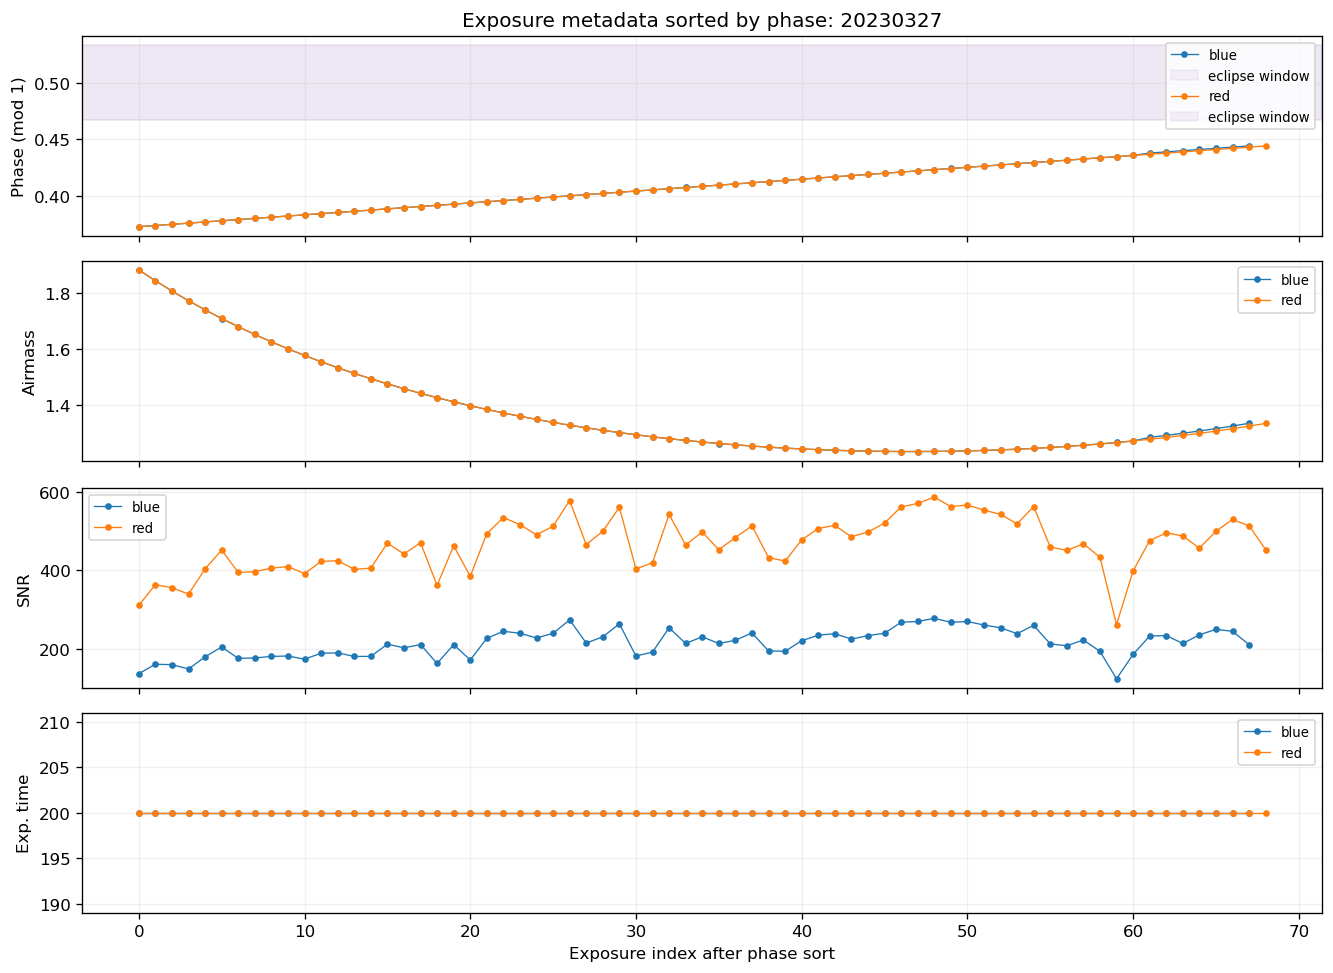

In [7]:
def plot_metadata_epoch(epoch, epoch_bundles):
    fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True, constrained_layout=True, gridspec_kw={"hspace": 0.08})
    for b in epoch_bundles:
        phase = phase_values(b)
        order = np.argsort(phase)
        label = b["arm"]
        x = np.arange(phase.size)
        axes[0].plot(x, phase[order], marker="o", ms=3, lw=0.8, label=label)
        if b["airmass"] is not None:
            axes[1].plot(x, np.asarray(b["airmass"], dtype=float)[order], marker="o", ms=3, lw=0.8, label=label)
        if b["snr"] is not None:
            axes[2].plot(x, np.asarray(b["snr"], dtype=float)[order], marker="o", ms=3, lw=0.8, label=label)
        if b["exptime"] is not None:
            axes[3].plot(x, np.asarray(b["exptime"], dtype=float)[order], marker="o", ms=3, lw=0.8, label=label)
        shade_phase_regions(axes[0], b)
    axes[0].set_ylabel("Phase" + (" (mod 1)" if PHASE_AXIS == "phase_mod1" else ""))
    axes[1].set_ylabel("Airmass")
    axes[2].set_ylabel("SNR")
    axes[3].set_ylabel("Exp. time")
    axes[3].set_xlabel("Exposure index after phase sort")
    axes[0].set_title(f"Exposure metadata sorted by phase: {epoch}")
    for ax in axes:
        ax.legend(loc="best")
    return fig, axes


epochs_to_plot = EPOCHS if MAX_EPOCHS_TO_PLOT is None else EPOCHS[:MAX_EPOCHS_TO_PLOT]
for epoch in epochs_to_plot:
    epoch_bundles = [b for b in bundles if b["epoch"] == epoch]
    if epoch_bundles:
        plot_metadata_epoch(epoch, epoch_bundles)
        plt.show()

## Phase-Ordered Time-Series Matrices

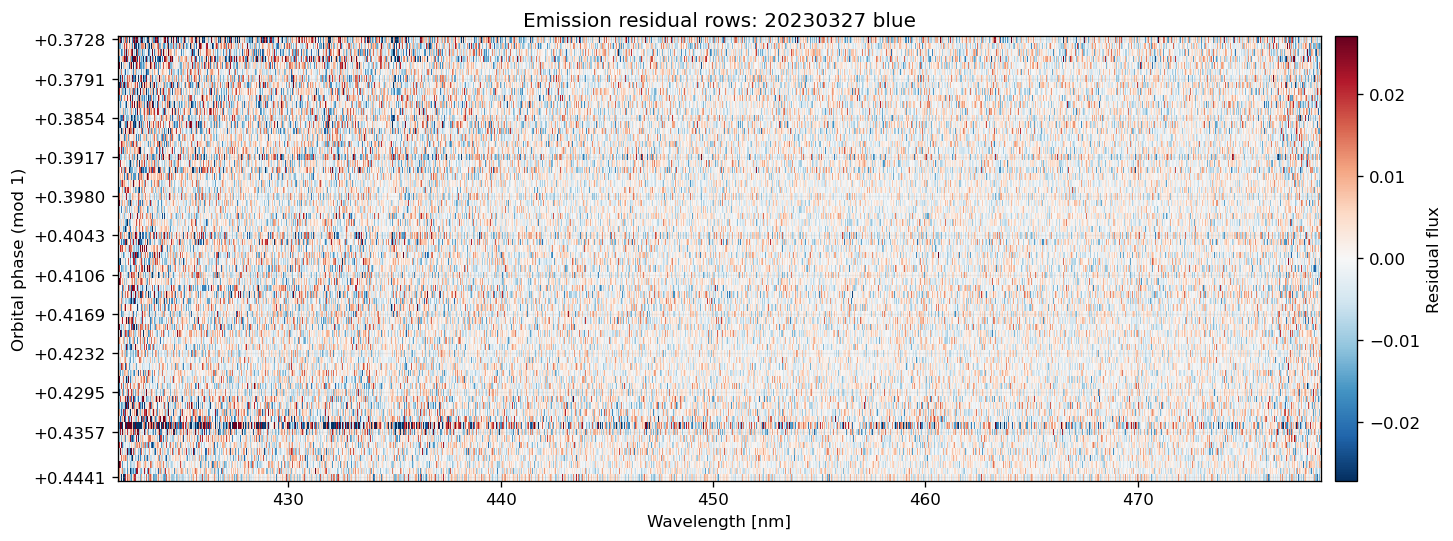

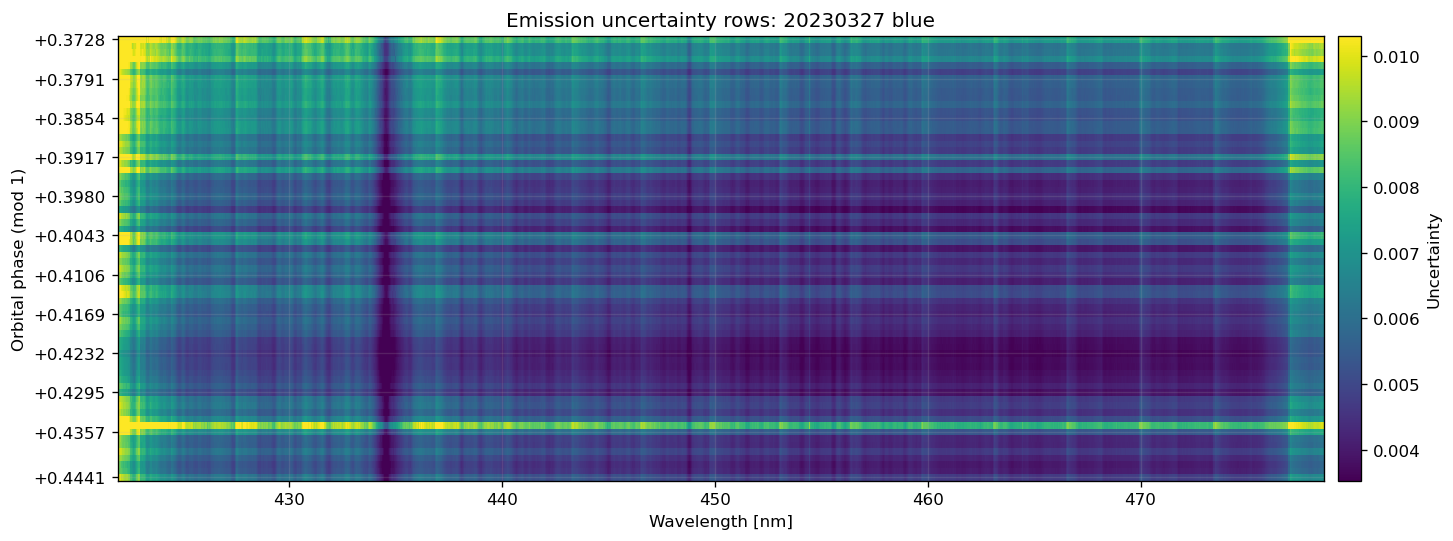

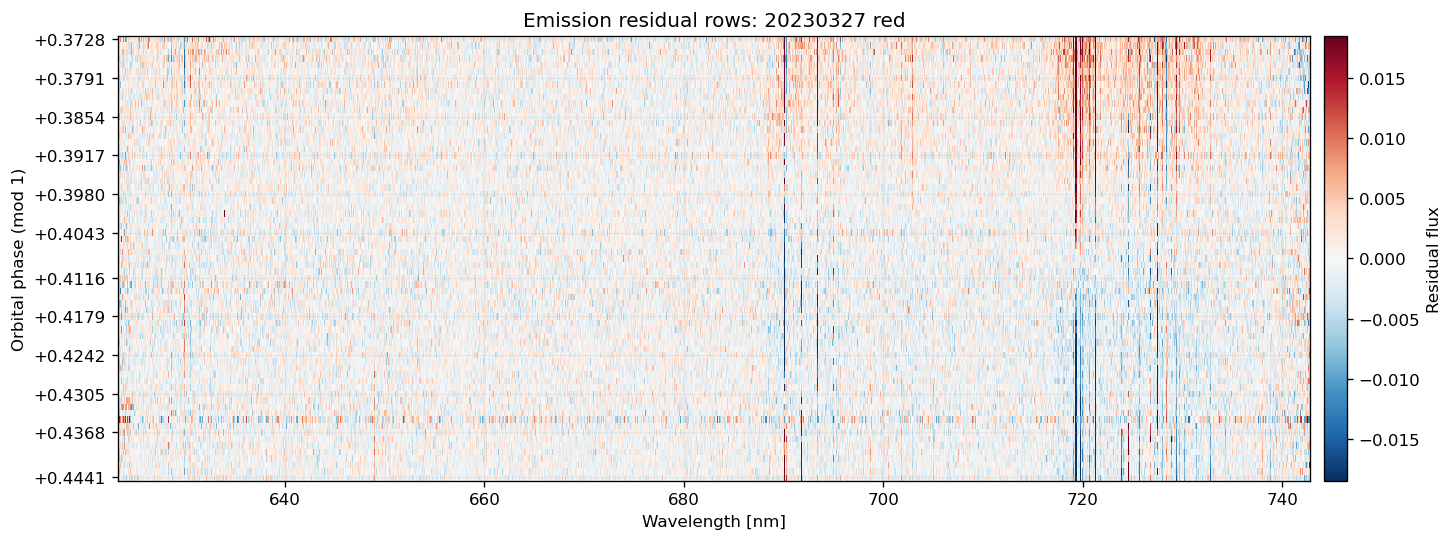

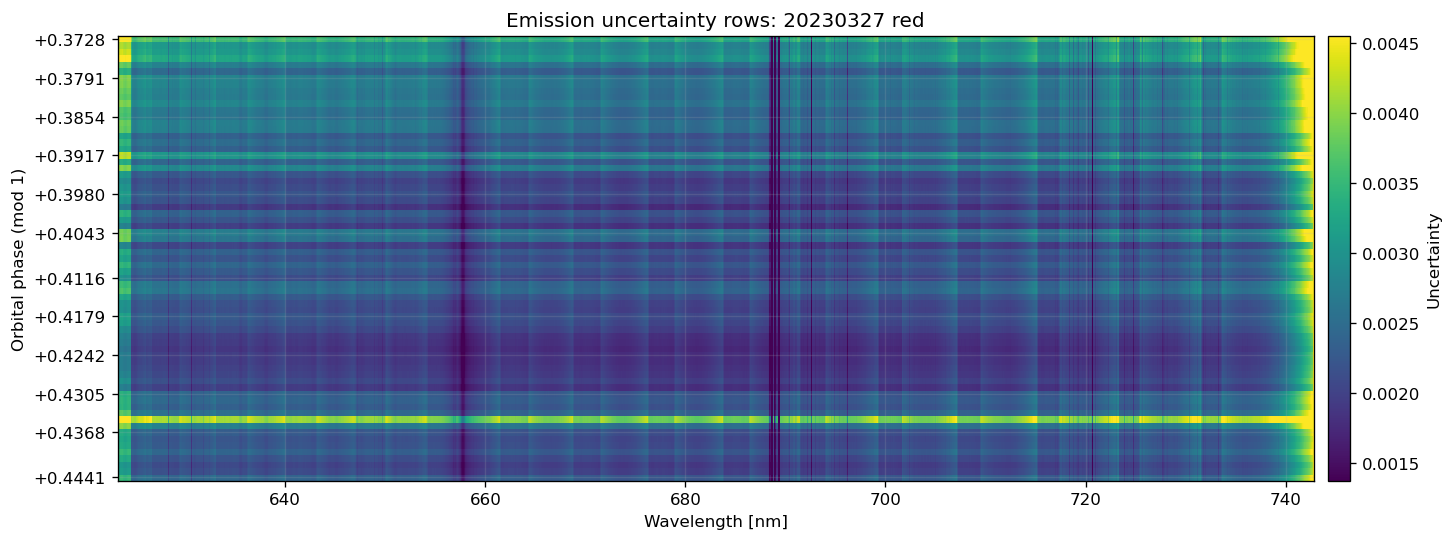

In [8]:
plot_bundles = bundles if MAX_EPOCHS_TO_PLOT is None else [b for b in bundles if b["epoch"] in EPOCHS[:MAX_EPOCHS_TO_PLOT]]
for b in plot_bundles:
    plot_matrix(b, "data", title=f"{MODE.title()} residual rows: {b['epoch']} {b['arm']}")
    plot_matrix(b, "sigma", title=f"{MODE.title()} uncertainty rows: {b['epoch']} {b['arm']}")
    plt.show()

## Per-Bundle Profiles

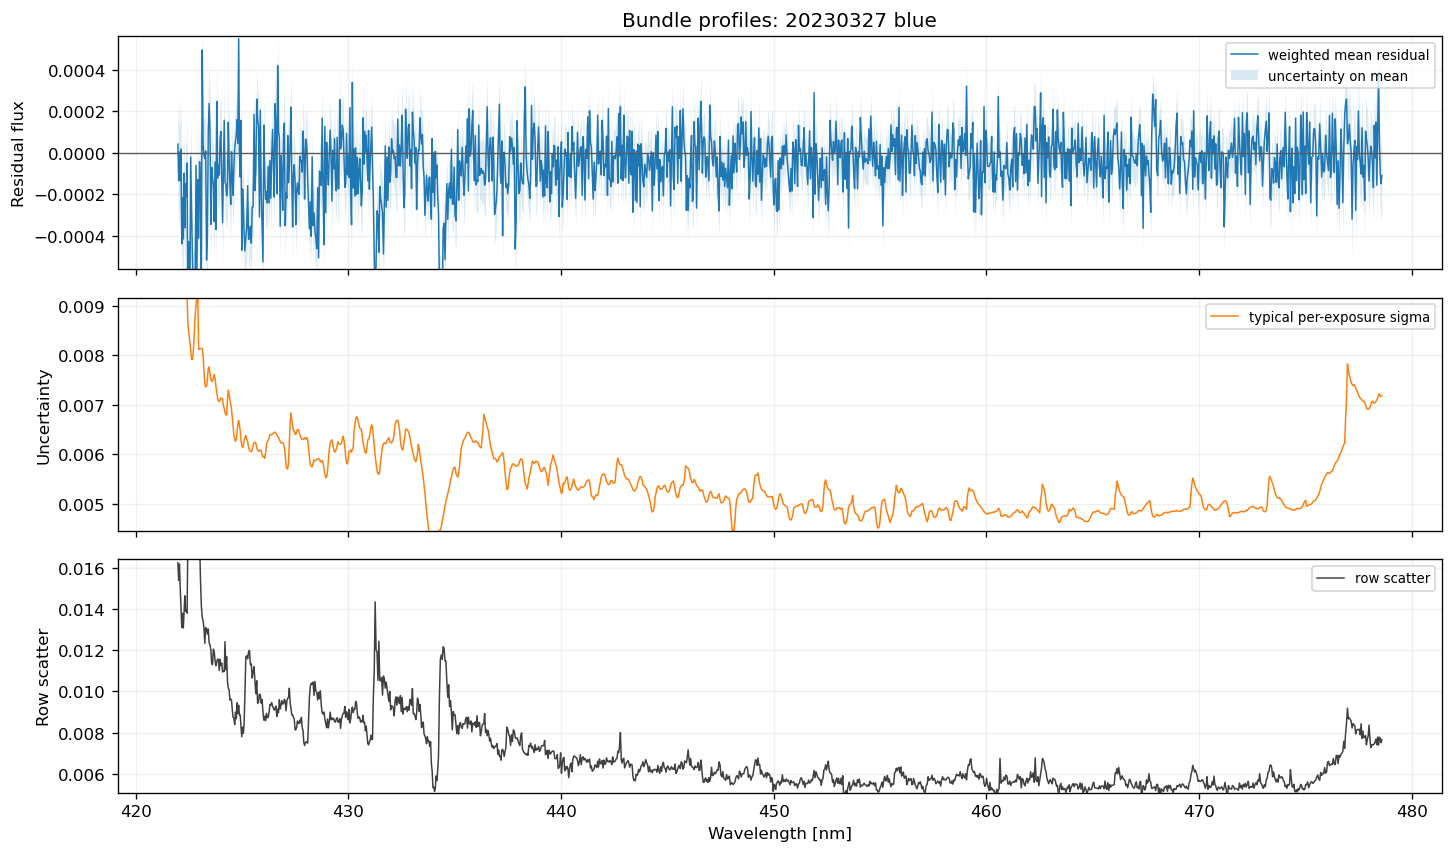

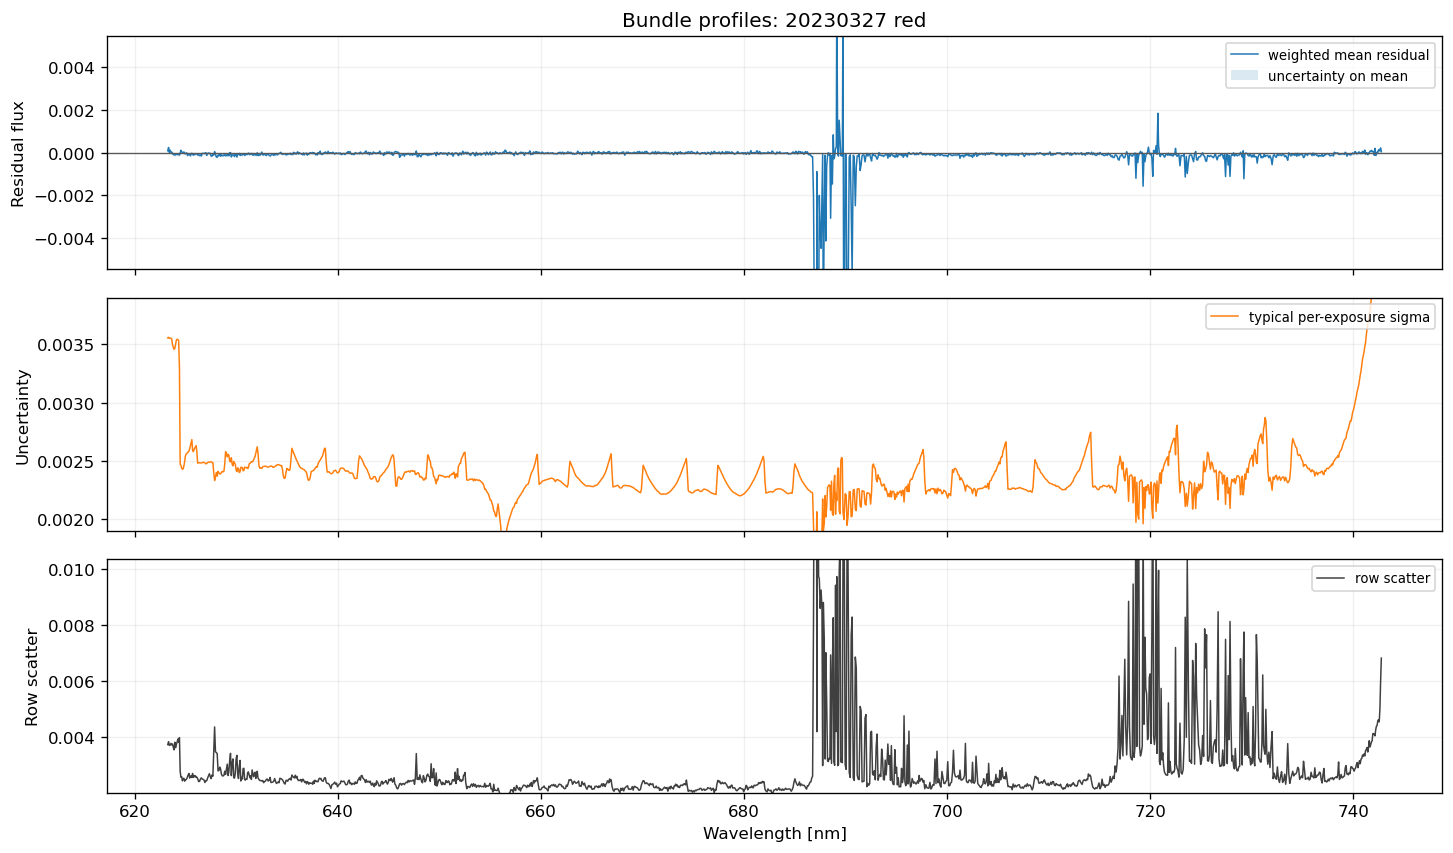

In [9]:
for b in plot_bundles:
    plot_profiles(b)
    plt.show()

## Observed Residual Summary

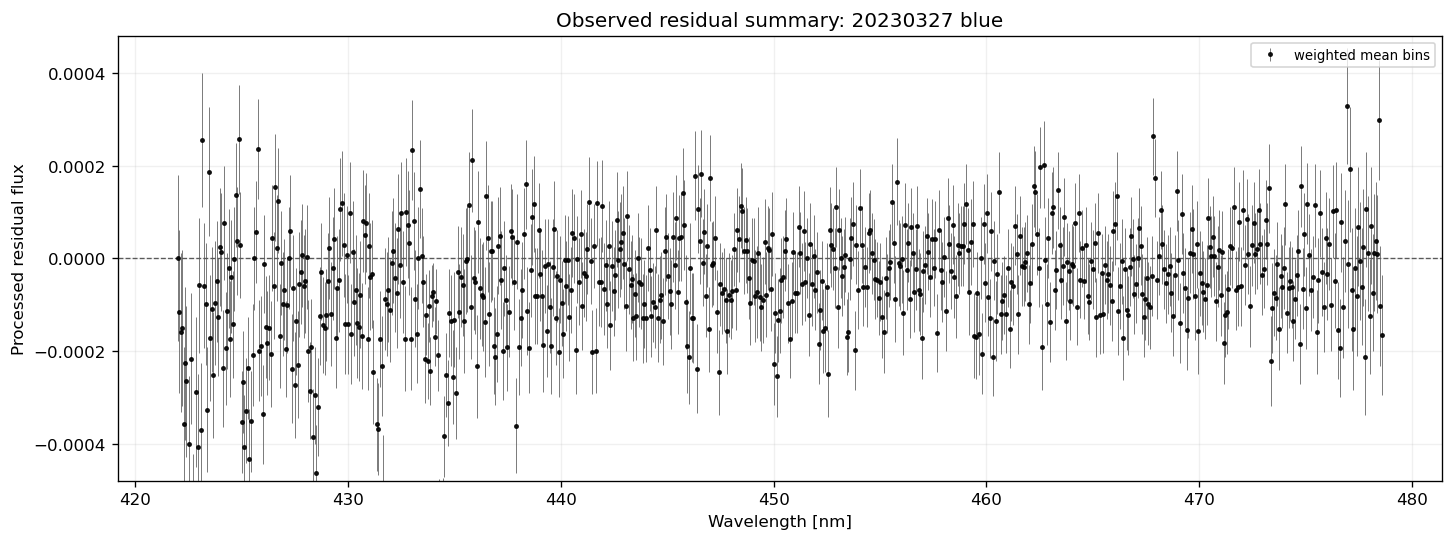

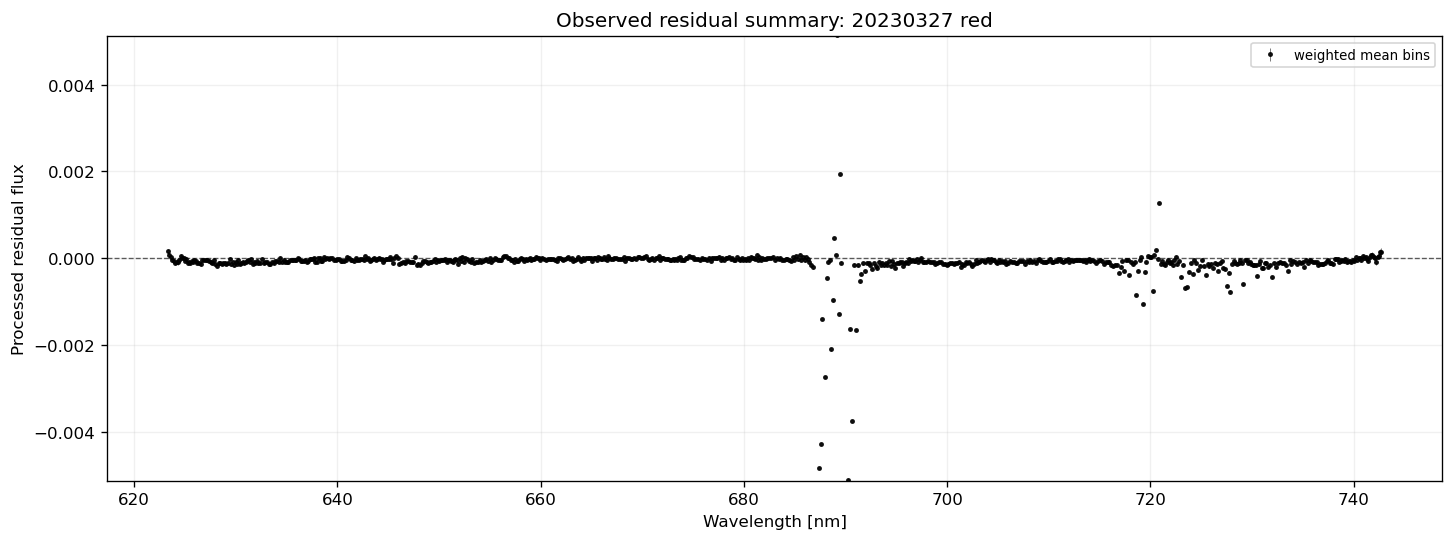

In [10]:
for b in plot_bundles:
    plot_observed_summary(b)
    plt.show()

## Collapsed Products On Disk

In [11]:
for b in plot_bundles:
    plot_collapsed_product(b)
    plt.show()

No collapsed emission product for 20230327 blue.
No collapsed emission product for 20230327 red.


## Epoch Comparison

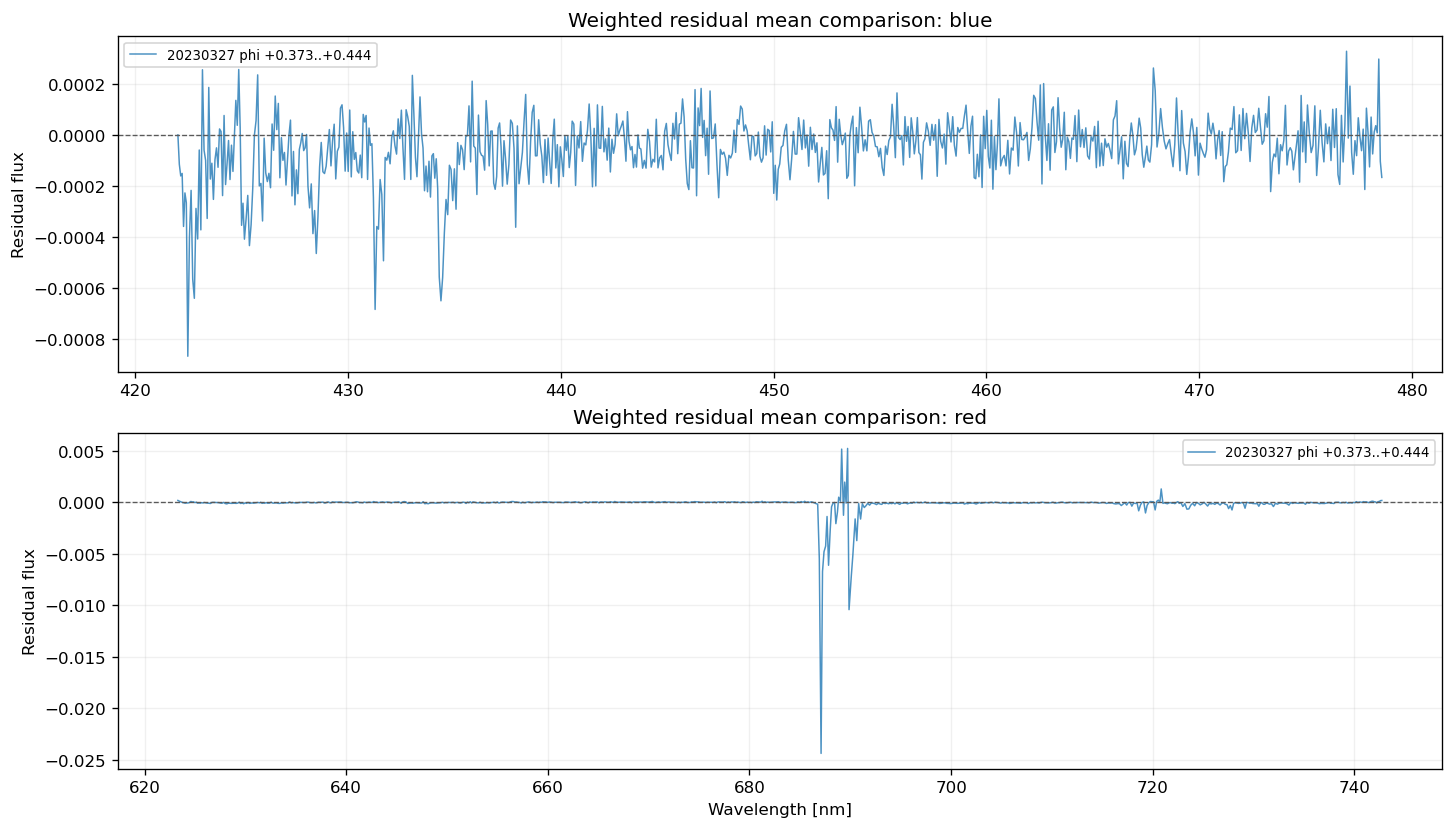

In [12]:
def compare_observed_by_arm(bundles):
    if not bundles:
        return None
    fig, axes = plt.subplots(len(ARMS), 1, figsize=(12, 3.4 * len(ARMS)), sharex=False, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, arm in zip(axes, ARMS):
        arm_bundles = [r for r in bundles if r["arm"] == arm]
        if not arm_bundles:
            ax.text(0.5, 0.5, f"No {arm} bundles", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for b in arm_bundles:
            stats = column_stats(b)
            wb, vb, _ = binned_series(b["wavelength"], stats["mean"], stats["err_mean"], max_bins=OBSERVED_MAX_BINS)
            phase = phase_values(b)
            ax.plot(display_wavelength_nm(wb), vb, lw=0.9, alpha=0.8, label=f"{b['epoch']} phi {np.nanmin(phase):+.3f}..{np.nanmax(phase):+.3f}")
        ax.axhline(0, color="0.35", lw=0.8, ls="--")
        ax.set_ylabel("Residual flux")
        ax.set_title(f"Weighted residual mean comparison: {arm}")
        ax.legend(loc="best")
    axes[-1].set_xlabel("Wavelength [nm]")
    return fig, axes


compare_observed_by_arm(bundles)
plt.show()

## Line Microscope

In [13]:
LINE_LIST = [
    {"label": "Ca II K", "rest_A": 3933.663, "arm": "blue"},
    {"label": "Ca II H", "rest_A": 3968.469, "arm": "blue"},
    {"label": "H beta", "rest_A": 4861.333, "arm": "blue"},
    {"label": "Mg I b 5167", "rest_A": 5167.321, "arm": "blue"},
    {"label": "Mg I b 5172", "rest_A": 5172.684, "arm": "blue"},
    {"label": "Mg I b 5183", "rest_A": 5183.604, "arm": "blue"},
    {"label": "Fe II 5169", "rest_A": 5169.033, "arm": "blue"},
    {"label": "Na I D2", "rest_A": 5889.951, "arm": "red"},
    {"label": "Na I D1", "rest_A": 5895.924, "arm": "red"},
    {"label": "H alpha", "rest_A": 6562.800, "arm": "red"},
    {"label": "Li I", "rest_A": 6707.800, "arm": "red"},
]
DEFAULT_LINE_LABELS = ("H beta", "Mg I b 5183", "H alpha")


def line_record(label):
    matches = [line for line in LINE_LIST if line["label"] == label]
    if not matches:
        raise KeyError(label)
    return matches[0]


pd.DataFrame(LINE_LIST)

,label,rest_A,arm
0,Ca II K,3933.663,blue
1,Ca II H,3968.469,blue
2,H beta,4861.333,blue
3,Mg I b 5167,5167.321,blue
4,Mg I b 5172,5172.684,blue
5,Mg I b 5183,5183.604,blue
6,Fe II 5169,5169.033,blue
7,Na I D2,5889.951,red
8,Na I D1,5895.924,red
9,H alpha,6562.800,red


In [14]:
def line_window_arrays(bundle, rest_A, window_kms=LINE_WINDOW_KMS):
    wave = np.asarray(bundle["wavelength"], dtype=float)
    velocity = CKMS * (wave / float(rest_A) - 1.0)
    keep = np.isfinite(velocity) & (np.abs(velocity) <= window_kms)
    return velocity[keep], bundle["data"][:, keep], bundle["sigma"][:, keep]


def stack_line(bundle, rest_A, window_kms=LINE_WINDOW_KMS, bin_kms=LINE_BIN_KMS):
    velocity, data, sigma = line_window_arrays(bundle, rest_A, window_kms=window_kms)
    if velocity.size < 4:
        return None
    v_grid = np.arange(-window_kms, window_kms + 0.5 * bin_kms, bin_kms)
    kp = resolved_kp()
    sum_w = np.zeros_like(v_grid, dtype=float)
    sum_yw = np.zeros_like(v_grid, dtype=float)
    for row, sig, phase in zip(data, sigma, bundle["phase"]):
        good = finite_good(row, sig)
        if np.count_nonzero(good) < 4:
            continue
        row_velocity = velocity[good]
        if kp is not None:
            row_velocity = row_velocity - planet_velocity_kms(phase)
        y = row[good]
        e = sig[good]
        interp_y = np.interp(v_grid, row_velocity, y, left=np.nan, right=np.nan)
        interp_e = np.interp(v_grid, row_velocity, e, left=np.nan, right=np.nan)
        valid = np.isfinite(interp_y) & np.isfinite(interp_e) & (interp_e > 0) & (interp_e < MASK_SIGMA_THRESHOLD)
        w = np.zeros_like(v_grid, dtype=float)
        w[valid] = 1.0 / np.square(interp_e[valid])
        sum_w += w
        sum_yw += np.where(valid, interp_y * w, 0.0)
    mean = np.divide(sum_yw, sum_w, out=np.full_like(v_grid, np.nan), where=sum_w > 0)
    err = np.divide(1.0, np.sqrt(sum_w), out=np.full_like(v_grid, np.nan), where=sum_w > 0)
    return v_grid, mean, err


def plot_line_microscope(bundle, line):
    rest_A = float(line["rest_A"])
    velocity, data, sigma = line_window_arrays(bundle, rest_A)
    if velocity.size < 4:
        print(f"{bundle['epoch']} {bundle['arm']} does not cover {line['label']} at {rest_A:.3f} A")
        return None
    order = phase_order(bundle)
    phase = phase_values(bundle)[order]
    raw_phase = bundle["phase"][order]
    mat = np.asarray(data, dtype=float)[order]
    sig = np.asarray(sigma, dtype=float)[order]
    mat = np.where(finite_good(mat, sig), mat, np.nan)
    limits = robust_limits(mat, percentile=99.2, symmetric=True, floor=2e-5)
    fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2), sharex=False, constrained_layout=True, gridspec_kw={"height_ratios": [2.2, 1.0], "hspace": 0.22})
    im = axes[0].imshow(
        mat,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=None if limits is None else limits[0],
        vmax=None if limits is None else limits[1],
        extent=[-LINE_WINDOW_KMS, LINE_WINDOW_KMS, len(order) - 0.5, -0.5],
    )
    kp = resolved_kp()
    if kp is not None:
        trail = planet_velocity_kms(raw_phase)
        axes[0].plot(trail, np.arange(len(phase)), color="gold", lw=1.0, ls="--", label="planet trail")
        axes[0].legend(loc="upper right")
    else:
        axes[0].text(0.02, 0.95, "Kp missing: no planet-trail overlay", transform=axes[0].transAxes, va="top", color="0.25")
    axes[0].axvline(0, color="0.25", lw=0.8, ls=":")
    ticks = np.arange(len(order))
    keep = ticks if len(ticks) <= 14 else np.unique(np.linspace(0, len(ticks) - 1, 12).astype(int))
    axes[0].set_yticks(keep)
    axes[0].set_yticklabels([f"{phase[i]:+.4f}" for i in keep])
    axes[0].set_ylabel("Orbital phase" + (" (mod 1)" if PHASE_AXIS == "phase_mod1" else ""))
    cb = fig.colorbar(im, ax=axes[0], pad=0.012, fraction=0.045)
    cb.set_label("Residual flux")

    stacked = stack_line(bundle, rest_A)
    if stacked is None:
        axes[1].text(0.5, 0.5, "No stack available", ha="center", va="center", transform=axes[1].transAxes)
    else:
        v_grid, mean, err = stacked
        axes[1].errorbar(v_grid, mean, yerr=err, fmt="o-", ms=2.0, lw=0.8, color="k", ecolor="0.45")
        axes[1].axhline(0, color="0.35", lw=0.8, ls="--")
        axes[1].axvline(0, color="0.25", lw=0.8, ls=":")
        lim = robust_limits(mean, percentile=98.5, symmetric=True, floor=2e-5)
        if lim:
            axes[1].set_ylim(*lim)
    frame_label = "planet-frame stack" if kp is not None else "rest-frame stack"
    axes[1].set_xlabel("Velocity around rest wavelength [km/s]")
    axes[1].set_ylabel(frame_label)
    axes[0].set_title(f"{line['label']} at {rest_A:.3f} A: {bundle['epoch']} {bundle['arm']}")
    return fig, axes

20230327 blue does not cover H beta at 4861.333 A
20230327 blue does not cover Mg I b 5183 at 5183.604 A


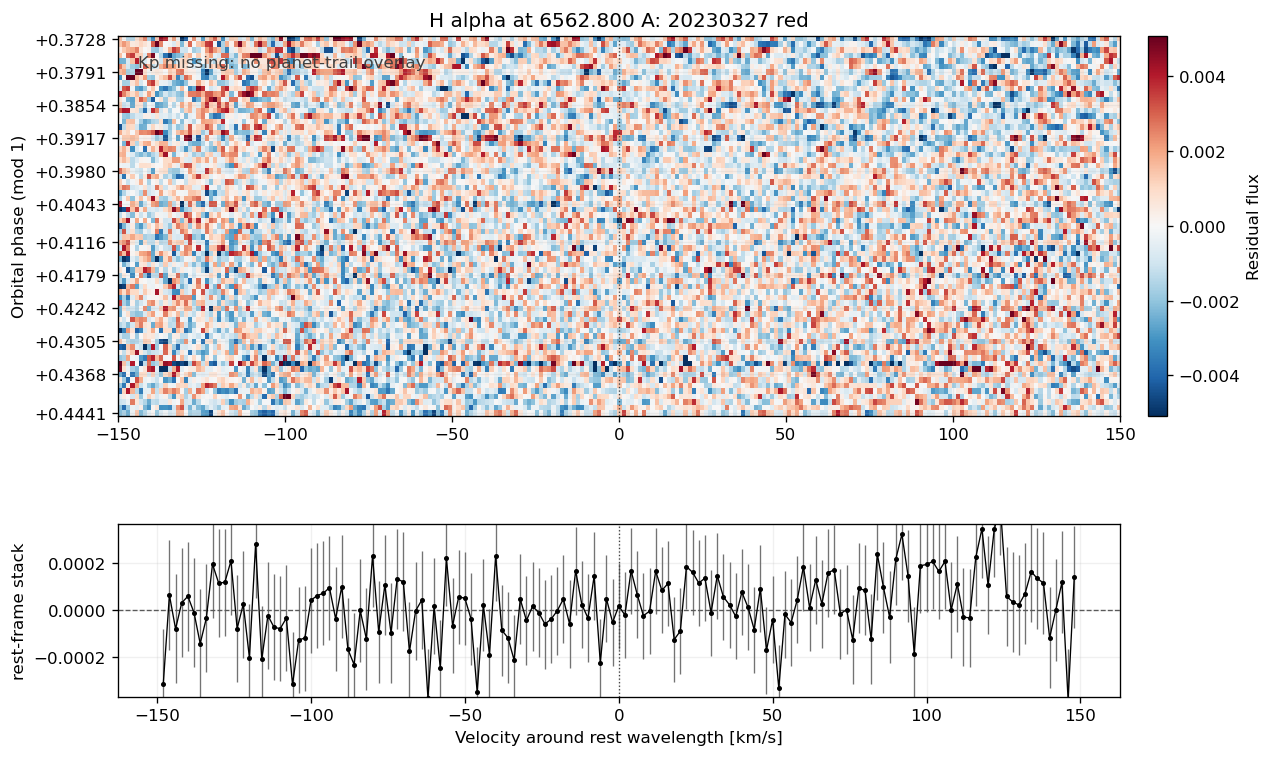

In [15]:
lines_to_plot = [line_record(label) for label in DEFAULT_LINE_LABELS]
for line in lines_to_plot:
    for b in plot_bundles:
        if b["arm"] != line["arm"]:
            continue
        plot_line_microscope(b, line)
        plt.show()

## SYSREM Products

In [16]:
def sysrem_summary_rows(bundles):
    rows = []
    for b in bundles:
        z = b.get("sysrem")
        if z is None:
            rows.append({"epoch": b["epoch"], "arm": b["arm"], "has_sysrem": False})
            continue
        row = {"epoch": b["epoch"], "arm": b["arm"], "has_sysrem": True, "files": tuple(z.files)}
        if "basis_counts" in z.files:
            row["basis_counts"] = np.asarray(z["basis_counts"]).tolist()
        if "chunk_names" in z.files:
            row["chunk_names"] = [str(x) for x in np.asarray(z["chunk_names"]).tolist()]
        rows.append(row)
    return rows


display(pd.DataFrame(sysrem_summary_rows(bundles)))

,epoch,arm,has_sysrem
0,20230327,blue,False
1,20230327,red,False


## Other Inputs On Disk

In [17]:
def inventory_tree(root: Path, max_files=80):
    if not root.exists():
        return pd.DataFrame([{"root": str(root.relative_to(REPO_ROOT)), "exists": False}])
    rows = []
    for path in sorted(root.rglob("*"))[:max_files]:
        rows.append({
            "path": str(path.relative_to(REPO_ROOT)),
            "kind": "dir" if path.is_dir() else "file",
            "size_mb": None if path.is_dir() else round(path.stat().st_size / 1024**2, 3),
        })
    return pd.DataFrame(rows)


display(inventory_tree(LRS_ROOT, max_files=80))
display(inventory_tree(PHOT_ROOT, max_files=80))

,root,exists
0,input/lrs/emission/wasp189b,False


,root,exists
0,input/phot/emission/wasp189b,False
